# Preprocessing

## Objective
In this notebook, we prepare the MRI dataset for deep learning using PyTorch.  
The goal is to transform raw MRI images into a clean, normalized, and model-ready dataset.

## Steps covered:
- Load dataset paths
- Understand class distribution
- Handle image resizing
- Normalize images
- Apply data augmentation (for training only)
- Create PyTorch Dataset & DataLoader

## 1) Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 2) Dataset Path
We check the dataset folders and classes to understand the problem.

In [2]:
BASE_DIR = os.path.abspath("..")

DATA_PATH = os.path.join(BASE_DIR, "data", "raw")
TRAIN_PATH = os.path.join(DATA_PATH, "train")
TEST_PATH = os.path.join(DATA_PATH, "test")

print(DATA_PATH)
print(os.path.exists(TRAIN_PATH))
classes = os.listdir(TRAIN_PATH)

/home/amrasmar/brain-tumor-mri-classification/data/raw
True


In [3]:
for c in classes:
    path = os.path.join(TRAIN_PATH, c)
    print(f"{c}: {len(os.listdir(path))}")

pituitary: 1457
no_tumor: 1067
meningioma: 1329
glioma: 1147


## 3) Show Samples
We display sample MRI images from each class to understand the data quality.

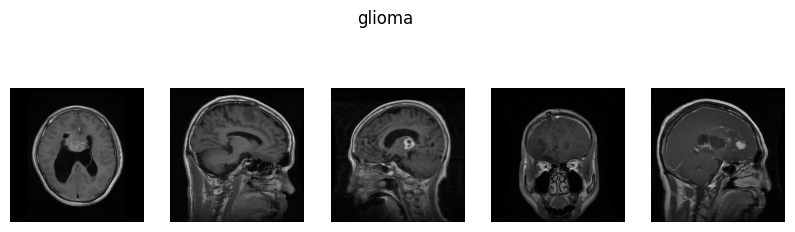

In [4]:
def show_samples(class_name):
    path = os.path.join(TRAIN_PATH, class_name)
    images = os.listdir(path)[:5]

    plt.figure(figsize=(10,3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.suptitle(class_name)
    plt.show()

show_samples("glioma")

## 4) Image Preprocessing & Augmentation

We prepare images for training by:
- Resizing images to fixed size (224x224)
- Converting images to tensors
- Normalizing pixel values
- Applying data augmentation (training only)

In [5]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

## 5) Class Distribution
We check the number of images in each class to understand dataset balance and detect any imbalance that may affect model training.

pituitary: 1457
no_tumor: 1067
meningioma: 1329
glioma: 1147


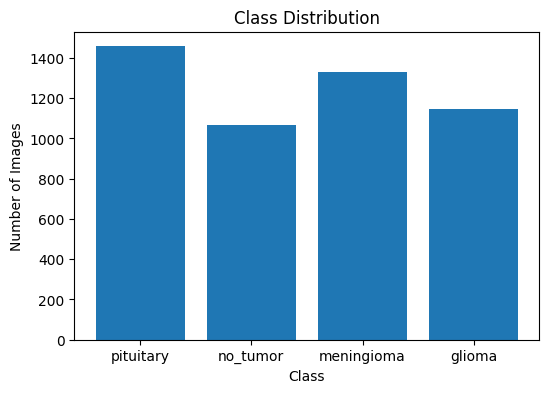

In [6]:
counts = {}
for c in classes:
    path = os.path.join(TRAIN_PATH, c)
    counts[c] = len(os.listdir(path))
    print(f"{c}: {counts[c]}")

plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## 6) Custom PyTorch Dataset
This class is responsible for loading images from folders, assigning labels to each class, and applying transformations so the data can be used by PyTorch models.

In [7]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))

        self.image_paths = []
        self.labels = []

        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)

            for img_name in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## 7) Create Dataset Objects
We create dataset instances for training and testing using our custom dataset class.

In [8]:
train_dataset = BrainTumorDataset(TRAIN_PATH, transform=train_transform)
test_dataset = BrainTumorDataset(TEST_PATH, transform=test_transform)

## 8) DataLoader
DataLoader is used to load data in batches, shuffle training data, and optimize training performance.

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)